计算卷积层中神经元的输出：
$
Z_{i,j,k} = b_k + 
\sum_{u=0}^{f_h-1} \sum_{v=0}^{f_w-1} \sum_{k'=0}^{f_{n'}-1}
x_{i',j',k'} \cdot W_{u,v,k',k}
\quad \text{其中}
\quad
\begin{cases}
i' = i \times s_h + u \\
j' = j \times s_w + v
\end{cases}
$

在此等式中：


**$Z_{i,j,k}$ 是位于卷积层（第1层）的特征图 $k$ 中第 $i$ 行 $j$ 列中的神经元的输出。**

**如前所述，$s_h$ 和 $s_w$ 是垂直步幅和水平步幅，$f_h$ 和 $f_w$ 是接受野的高度和宽度，$f_{n'}$ 是上一层（层 $l-1$）中特征图的数量。**

**$x_{i',j',k'}$ 是位于第 $l-1$ 层、第 $i'$ 行、第 $j'$ 列、特征图 $k'$（或通道 $k'$；如果前一层是输入层）的神经元的输出。**

**$b_k$ 是特征图 $k$（在第1层中）的偏置项。你可以将其视为用于调整特征图 $k$ 整体亮度的旋钮。**

**$W_{u, v, k^{'}, k}$ 是层1的特征图$k$中的任何神经元与其位于 $u$ 行、$v$ 列（相对于神经元的接受野）和特征图 $k$ 的输入之间的连接权重**


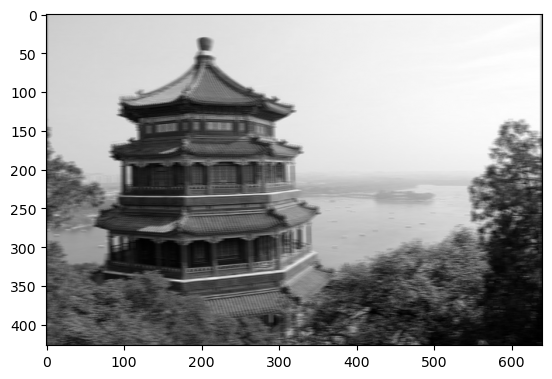

In [ ]:
#卷积层

#在TensorFlow中，每个输入图像通常表示为形状为[height，width，channels]的3D张量。
#小批量表示为形状为[mini batch size，height，width，channels]的4D张量。
#卷积层的权重表示为形状为[ h，w，n'，n]的4D张量。卷积层的偏置项简单表示为形状[ n]的一维张量。
from sklearn.datasets import load_sample_image
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

first = load_sample_image("china.jpg") / 255
second = load_sample_image("flower.jpg") / 255
images = np.array([first, second])
batch_size, height, width, channels = images.shape

filters = np.zeros(shape=(7, 7, channels, 2), dtype=np.float32)
filters[:, 3, :, 0] = 1 #vertical line
filters[3, :, :, 1] = 1 #horizontal line

outputs = tf.nn.conv2d(images, filters, strides=1, padding="SAME")

plt.imshow(outputs[0, :, :, 1], cmap="gray")
plt.show()

In [ ]:
#池化层

max_pool = keras.layers.MaxPool2D(pool_size=2)
output = tf.nn.max_pool(images, ksize=(1, 1, 1, 3), strides=(1, 1, 1, 3), padding="valid")
depth_pool = keras.layers.Lambda( lambda X: tf.nn.max_pool(X, ksize=(1, 1, 1, 3), strides=(1, 1, 1, 3), padding="valid")) 
global_avg_pool = keras.layers.GlobalAvgPool2D() 
global_avg_pool = keras.layers.Lambda(lambda X: tf.reduce_mean(X, axis=[1, 2]))

In [ ]:
#a example model
model = keras.models.Sequential([ 
    keras.layers.Conv2D(64, 7, activation="relu", padding="same", input_shape=[28, 28, 1]), 
    keras.layers.MaxPooling2D(2), 
    keras.layers.Conv2D(128, 3, activation="relu", padding="same"), 
    keras.layers.Conv2D(128, 3, activation="relu", padding="same"), 
    keras.layers.MaxPooling2D(2), 
    keras.layers.Conv2D(256, 3, activation="relu", padding="same"), 
    keras.layers.Conv2D(256, 3, activation="relu", padding="same"), 
    keras.layers.MaxPooling2D(2), 
    keras.layers.Flatten(), 
    keras.layers.Dense(128, activation="relu"), 
    keras.layers.Dropout(0.5), 
    keras.layers.Dense(64, activation="relu"), 
    keras.layers.Dropout(0.5), 
    keras.layers.Dense(10, activation="softmax") 
]) 

局部响应归一化：

$$
b_i = a_i \left( k + a \sum_{j=j_{\text{low}}}^{j_{\text{high}}} a_j^2 \right)^{-\beta}
\quad \text{其中} \quad
\begin{cases}
j_{\text{high}} = \min\!\left(i + \frac{r}{2},\, f_n - 1\right) \\
j_{\text{low}} = \max\!\left(0,\, i - \frac{r}{2}\right)
\end{cases}
$$

公式中：

- $b_i$ 是位于特征图 $i$ 中位于 $u$ 行和 $v$ 列的神经元的归一化输出（请注意在此公式中，我们仅考虑位于此行和列的神经元，因此未显示 $u$ 和 $v$）。
- $a_i$ 是 ReLU 之后但未归一化之前该神经元的激活。
- $k$、$a$、$\beta$ 和 $r$ 是超参数。$k$ 称为偏置，$r$ 称为深度半径。
- $f_n$ 是特征图的数量。